<a href="https://colab.research.google.com/github/ronith-raj/SYNTECXHUB/blob/main/TASK_4_(PROJECT_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/content/Cricket_data.csv')

df.head()

,season,id,name,short_name,description,home_team,away_team,toss_won,decision,1st_inning_score,...,home_playx1,away_playx1,away_key_batsman,away_key_bowler,match_days,umpire1,umpire2,tv_umpire,referee,reserve_umpire
0,NaN,1370350,Chennai Super Kings v Gujarat Titans,CSK v GT,"Qualifier 1 (N), Indian Premier League at Chen...",CSK,GT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1370351,Lucknow Super Giants v Mumbai Indians,LSG v MI,"Eliminator (N), Indian Premier League at Chenn...",LSG,MI,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1370352,TBC v TBC,TBC v TBC,"Qualifier 2 (N), Indian Premier League at Ahme...",TBA,TBA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,1370353,TBC v TBC,TBC v TBC,"Final (N), Indian Premier League at Ahmedabad,...",TBA,TBA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023.0,1359544,Royal Challengers Bangalore v Gujarat Titans,RCB v GT,"70th Match (N), Indian Premier League at Benga...",RCB,GT,GT,BOWL FIRST,197/5,...,"Virat Kohli (UKN),Faf du Plessis (UKN),Glenn M...","Wriddhiman Saha (WK),Shubman Gill (UKN),Vijay ...","Shubman Gill,Vijay Shankar","Noor Ahmad,Rashid Khan",21 May 2023 - night match (20-over match),Nitin Menon,Virender Sharma,Tapan Sharma,Javagal Srinath,VM Dhokre


In [3]:
print(df.columns)
df.info()

Index(['season', 'id', 'name', 'short_name', 'description', 'home_team',
       'away_team', 'toss_won', 'decision', '1st_inning_score',
       '2nd_inning_score', 'winner', 'result', 'start_date', 'end_date',
       'venue_id', 'venue_name', 'home_captain', 'away_captain', 'pom',
       'points', 'super_over', 'home_overs', 'home_runs', 'home_wickets',
       'home_boundaries', 'away_overs', 'away_runs', 'away_wickets',
       'away_boundaries', 'highlights', 'home_key_batsman', 'home_key_bowler',
       'home_playx1', 'away_playx1', 'away_key_batsman', 'away_key_bowler',
       'match_days', 'umpire1', 'umpire2', 'tv_umpire', 'referee',
       'reserve_umpire'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            1027 non-null   float64
 1   id                1032 non-null   int64  
 2   name 

In [4]:
# Try to automatically detect columns

player_col = None
runs_col = None
team_col = None

for col in df.columns:
    if 'bat' in col.lower() or 'player' in col.lower():
        player_col = col
    if 'run' in col.lower():
        runs_col = col
    if 'team' in col.lower():
        team_col = col

print("Player column:", player_col)
print("Runs column:", runs_col)
print("Team column:", team_col)

Player column: away_key_batsman
Runs column: away_runs
Team column: away_team


In [5]:
df = df.dropna(subset=[player_col, runs_col])

In [6]:
balls = df.groupby(player_col).size()
runs = df.groupby(player_col)[runs_col].sum()

strike_rate = (runs / balls) * 100

sr_df = pd.DataFrame({
    'runs': runs,
    'balls': balls,
    'strike_rate': strike_rate
})

# filter players with enough balls
sr_df = sr_df[sr_df['balls'] > 50]

top_sr = sr_df.sort_values('strike_rate', ascending=False).head(10)

top_sr

,runs,balls,strike_rate
away_key_batsman,,,


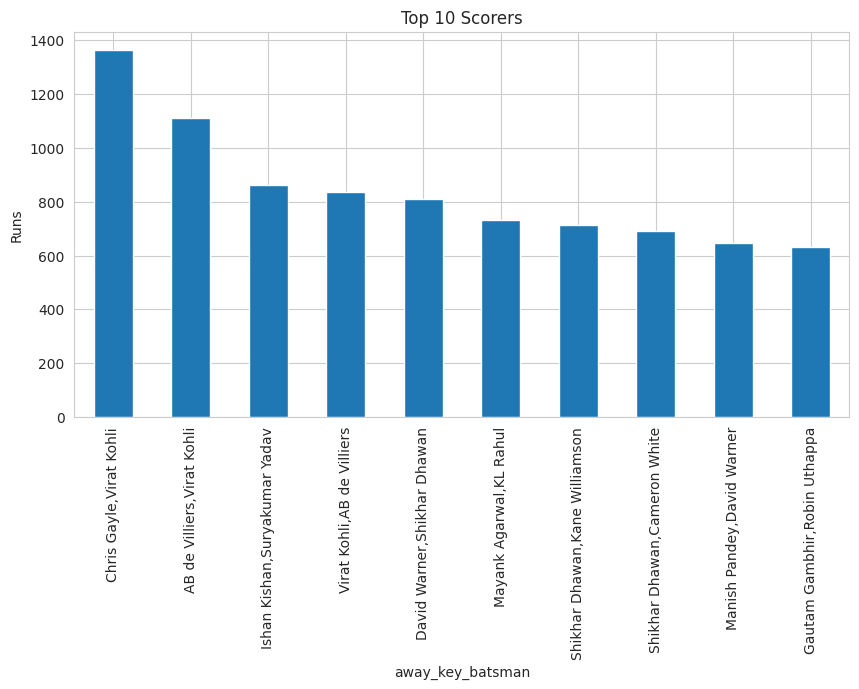

In [7]:
top_scorers = df.groupby(player_col)[runs_col].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_scorers.plot(kind='bar')
plt.title("Top 10 Scorers")
plt.ylabel("Runs")
plt.show()

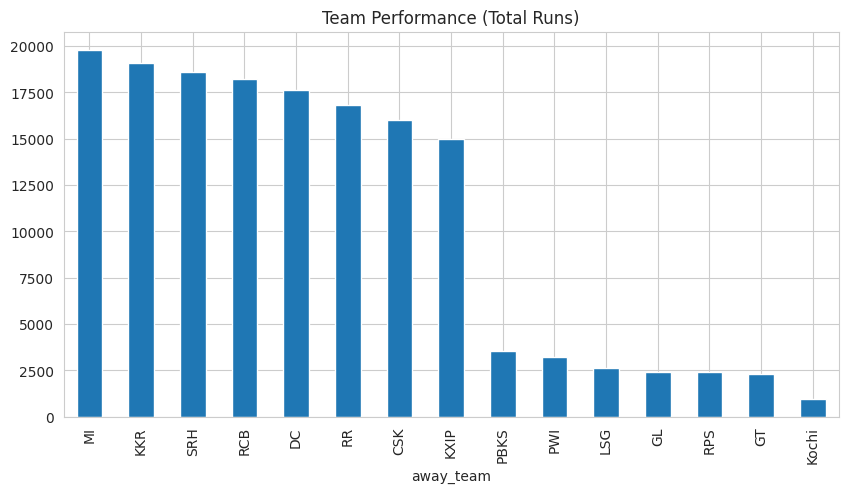

In [8]:
if team_col:
    team_runs = df.groupby(team_col)[runs_col].sum().sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    team_runs.plot(kind='bar')
    plt.title("Team Performance (Total Runs)")
    plt.show()

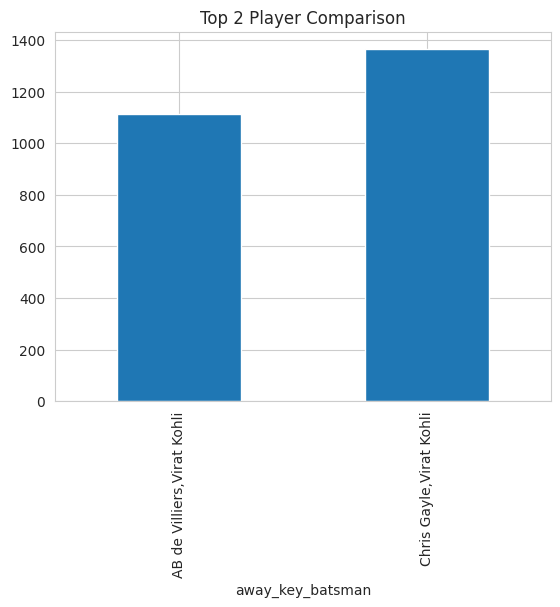

In [9]:
top_players = df[player_col].value_counts().head(2).index

comparison = df[df[player_col].isin(top_players)]
comparison = comparison.groupby(player_col)[runs_col].sum()

comparison.plot(kind='bar', title="Top 2 Player Comparison")
plt.show()

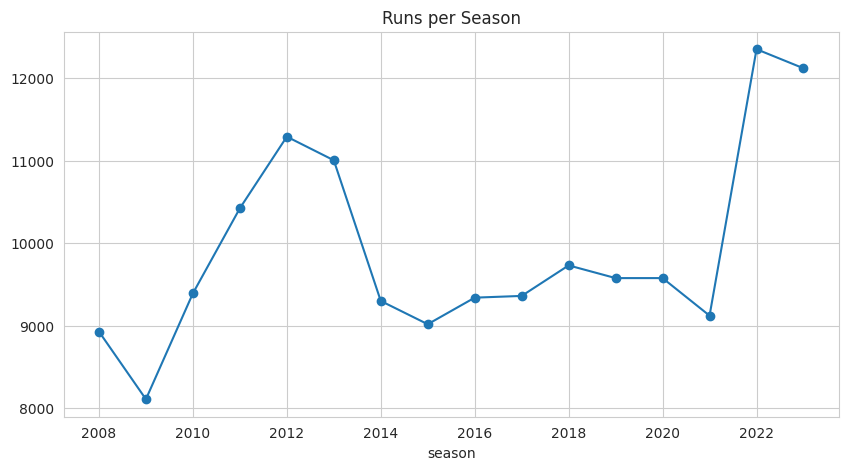

In [10]:
season_col = None

for col in df.columns:
    if 'season' in col.lower() or 'year' in col.lower():
        season_col = col

if season_col:
    season_runs = df.groupby(season_col)[runs_col].sum()

    plt.figure(figsize=(10,5))
    season_runs.plot(marker='o')
    plt.title("Runs per Season")
    plt.show()

In [11]:
top_scorers.to_csv("top_scorers.csv")
sr_df.to_csv("strike_rates.csv")

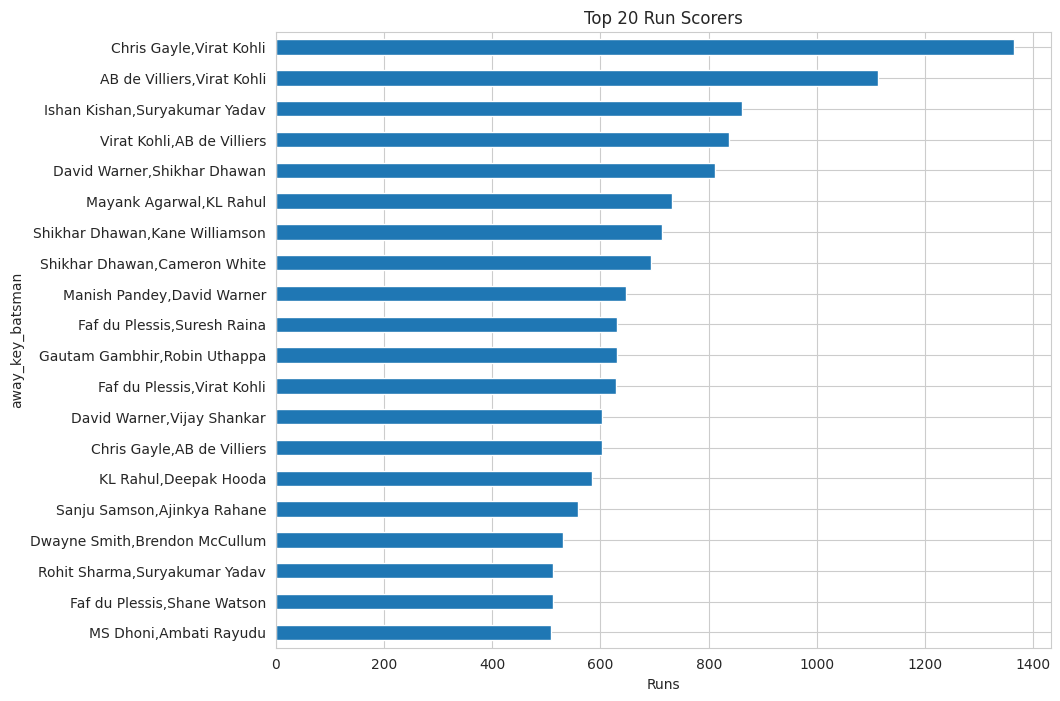

In [12]:
top20 = df.groupby(player_col)[runs_col].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))
top20.sort_values().plot(kind='barh')
plt.title("Top 20 Run Scorers")
plt.xlabel("Runs")
plt.show()

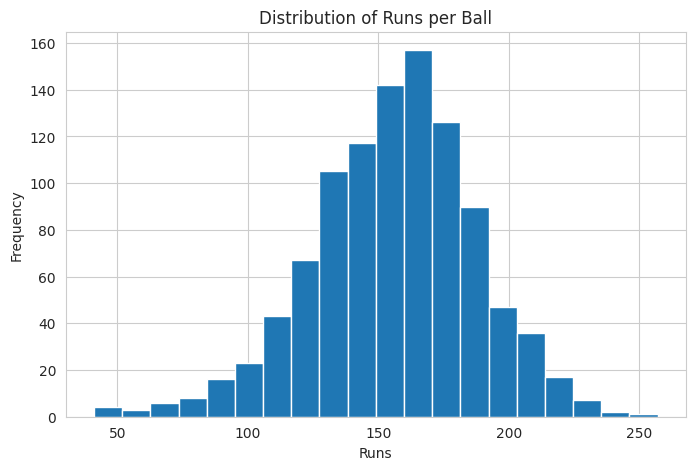

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df[runs_col], bins=20)
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

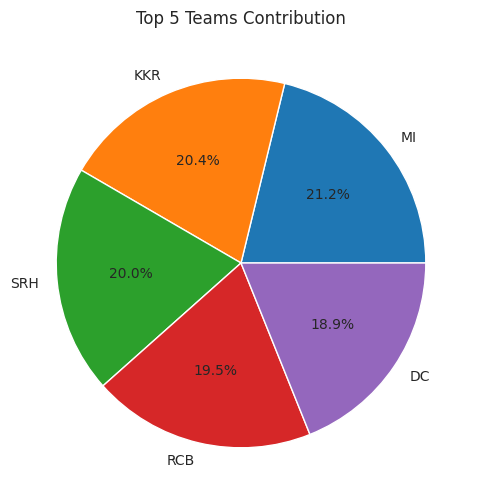

In [14]:
if team_col:
    team_runs = df.groupby(team_col)[runs_col].sum().sort_values(ascending=False).head(5)

    plt.figure(figsize=(6,6))
    plt.pie(team_runs, labels=team_runs.index, autopct='%1.1f%%')
    plt.title("Top 5 Teams Contribution")
    plt.show()

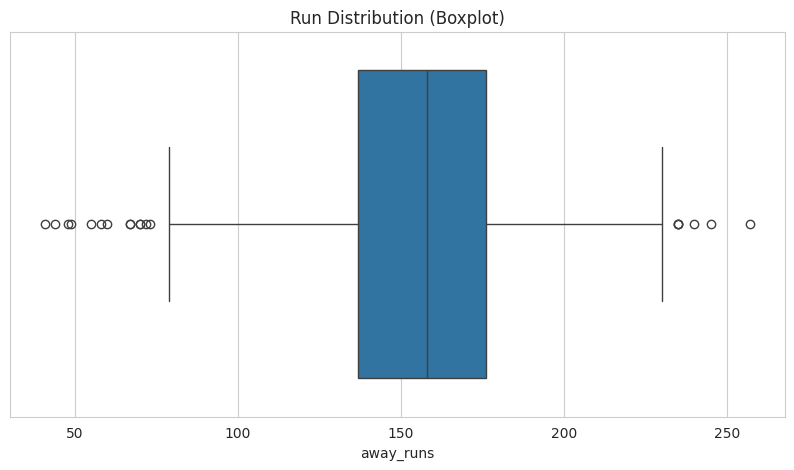

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df[runs_col])
plt.title("Run Distribution (Boxplot)")
plt.show()

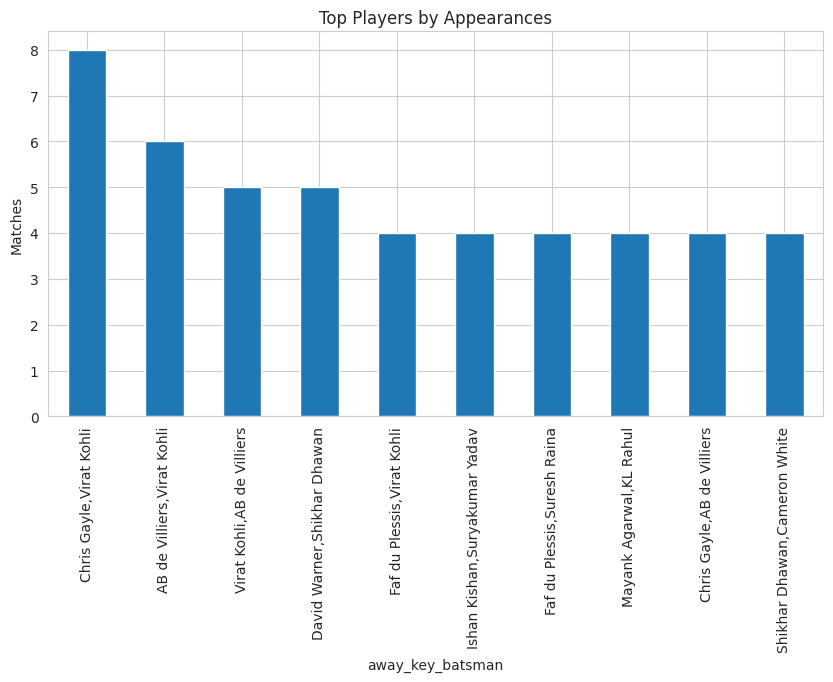

In [16]:
matches_played = df[player_col].value_counts().head(10)

plt.figure(figsize=(10,5))
matches_played.plot(kind='bar')
plt.title("Top Players by Appearances")
plt.ylabel("Matches")
plt.show()

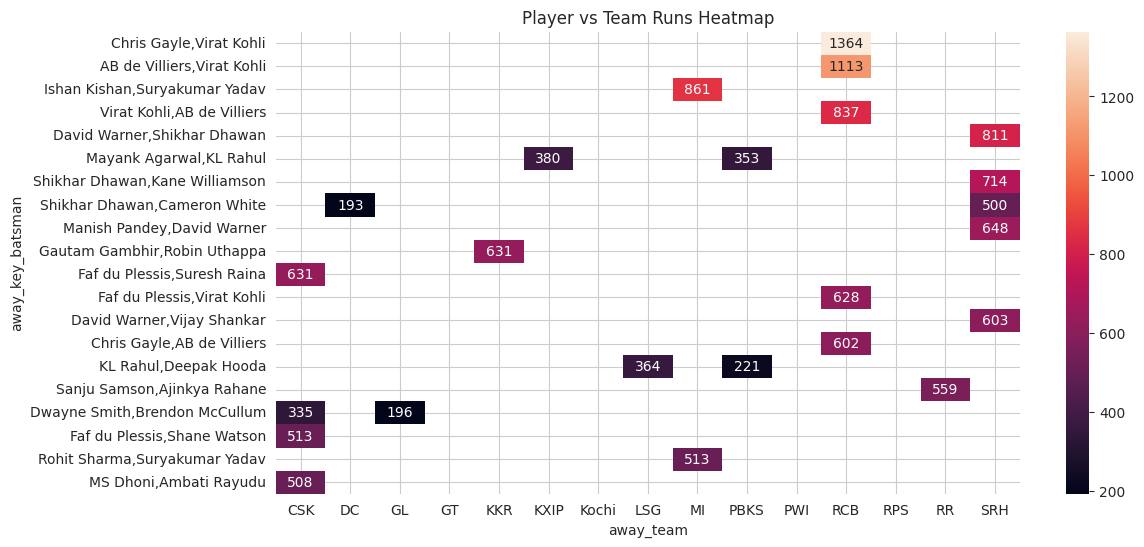

In [17]:
if team_col:
    pivot = pd.pivot_table(df, values=runs_col, index=player_col, columns=team_col, aggfunc='sum')

    top_players = top20.index
    pivot = pivot.loc[top_players]

    plt.figure(figsize=(12,6))
    sns.heatmap(pivot, annot=True, fmt=".0f")
    plt.title("Player vs Team Runs Heatmap")
    plt.show()

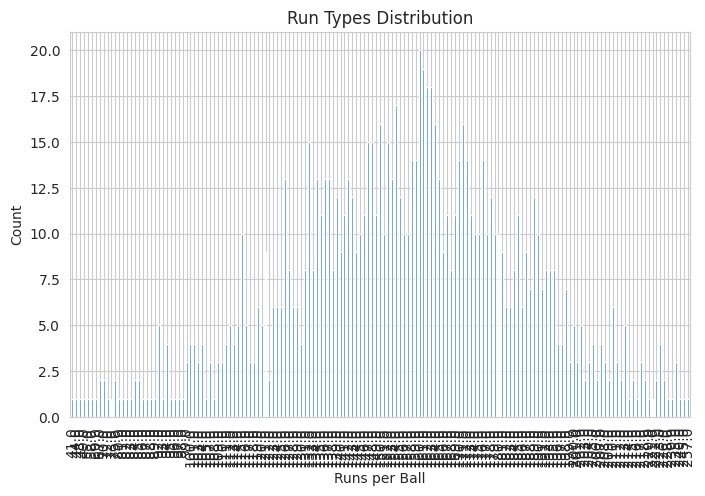

In [18]:
run_counts = df[runs_col].value_counts().sort_index()

plt.figure(figsize=(8,5))
run_counts.plot(kind='bar')
plt.title("Run Types Distribution")
plt.xlabel("Runs per Ball")
plt.ylabel("Count")
plt.show()